In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Dataset, random_split
import random

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

transform = transforms.Compose([transforms.Resize((128, 128)), transforms.ToTensor()])
full_dataset = datasets.ImageFolder(root= 'data/PlantVillage/train', transform= transform)

healthy_classes = [cls for cls, idx in full_dataset.class_to_idx.items() if '___healthy' in cls]
diseased_classes = [cls for cls, idx in full_dataset.class_to_idx.items() if '___healthy' not in cls]

healthy_indices = [i for i, (_, label) in enumerate(full_dataset.samples) if full_dataset.classes[label] in healthy_classes]
diseased_indices = [i for i, (_, label) in enumerate(full_dataset.samples) if full_dataset.classes[label] in diseased_classes]

healthy_dataset = torch.utils.data.Subset(full_dataset, healthy_indices)

train_size = int(0.8 * len(healthy_dataset))
val_size = len(healthy_dataset) - train_size
train_healthy, val_healthy = random_split(healthy_dataset, [train_size, val_size])

train_loader = DataLoader(train_healthy, batch_size= 64, shuffle= True, num_workers= 4, pin_memory= True)
val_loader = DataLoader(val_healthy, batch_size= 64, shuffle= False, num_workers= 4, pin_memory= True)

diseased_dataset = torch.utils.data.Subset(full_dataset, diseased_indices)
diseased_loader = DataLoader(diseased_dataset, batch_size= 64, shuffle= False, num_workers= 4, pin_memory= True)

print(f"Healthy train: {len(train_healthy)}, Healthy val: {len(val_healthy)}")
print(f"Diseased test: {len(diseased_dataset)}")
print(f"Number of disease categories: {len(diseased_classes)}")

Healthy train: 9654, Healthy val: 2414
Diseased test: 31376
Number of disease categories: 26


In [2]:
class Encoder(nn.Module):
    def __init__(self, in_channels=3, latent_dim=128):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=4, stride=2, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)       
        self.conv4 = nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1) 
        self.fc_mu = nn.Linear(256 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(256 * 8 * 8, latent_dim)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

class Decoder(nn.Module):
    def __init__(self, latent_dim=128, out_channels=3):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 256 * 8 * 8)
        self.deconv1 = nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1)
        self.deconv2 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)
        self.deconv3 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        self.deconv4 = nn.ConvTranspose2d(32, out_channels, kernel_size=4, stride=2, padding=1)
        self.out_act = nn.Sigmoid()

    def forward(self, z):
        x = self.fc(z)
        x = x.view(x.size(0), 256, 8, 8)
        x = F.relu(self.deconv1(x))
        x = F.relu(self.deconv2(x))
        x = F.relu(self.deconv3(x))
        x = self.deconv4(x)
        x = self.out_act(x)
        return x

class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = Encoder(latent_dim=latent_dim)
        self.decoder = Decoder(latent_dim=latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum') / x.size(0)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon_loss + beta * kl_loss, recon_loss, kl_loss

Epoch 1/5 | Train Loss: 32248.0586 | Val Loss: 31355.4570
Epoch 2/5 | Train Loss: 31065.7193 | Val Loss: 30997.3035
Epoch 3/5 | Train Loss: 30823.8630 | Val Loss: 30810.2710
Epoch 4/5 | Train Loss: 30704.2187 | Val Loss: 30712.3802
Epoch 5/5 | Train Loss: 30623.1389 | Val Loss: 30665.5841


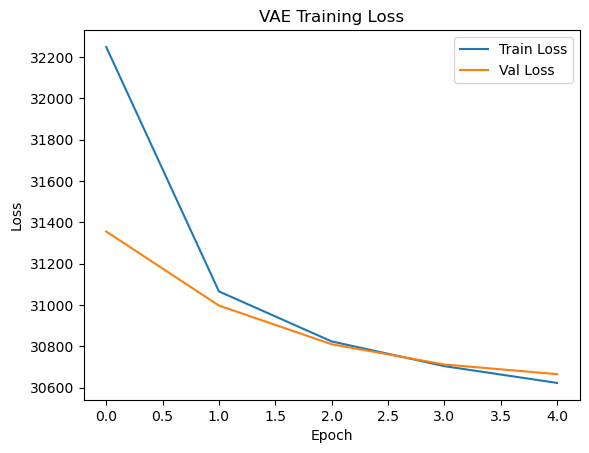

Anomaly threshold (95% percentile of healthy val errors): 0.011674
Disease detection AUC: 0.6676, F1-score: 0.2822


In [5]:
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def train_vae(model, train_loader, val_loader, epochs, lr, beta= 1.0, device= device):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr= lr)
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0.0
        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.to(device)
            optimizer.zero_grad()
            recon, mu, logvar = model(data)
            loss, recon_loss, kl_loss = vae_loss(recon, data, mu, logvar, beta=beta)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()
        
        avg_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        model.eval()
        epoch_val_loss = 0.0
        with torch.no_grad():
            for data, _ in val_loader:
                data = data.to(device)
                recon, mu, logvar = model(data)
                loss, _, _ = vae_loss(recon, data, mu, logvar, beta=beta)
                epoch_val_loss += loss.item()
        avg_val_loss = epoch_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), 'models/vae_healthy.pth')
    
    plt.figure()
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('VAE Training Loss')
    plt.savefig('vae_loss_plot.png')
    plt.show()
    return model

def compute_reconstruction_error(model, dataloader, device=device):
    model.eval()
    errors = []
    with torch.no_grad():
        for data, _ in dataloader:
            data = data.to(device)
            recon, _, _ = model(data)
            mse = F.mse_loss(recon, data, reduction='none').view(data.size(0), -1).mean(dim=1)
            errors.extend(mse.cpu().numpy())
    return np.array(errors)

vae = VAE(latent_dim=128).to(device)

vae = train_vae(vae, train_loader, val_loader, epochs=5, lr=1e-3, beta=1.0, device=device)

val_healthy_errors = compute_reconstruction_error(vae, val_loader, device=device)
diseased_errors = compute_reconstruction_error(vae, diseased_loader, device=device)

threshold = np.percentile(val_healthy_errors, 95)
print(f"Anomaly threshold (95% percentile of healthy val errors): {threshold:.6f}")

y_true = [0]*len(val_healthy_errors) + [1]*len(diseased_errors)
y_pred = (np.concatenate([val_healthy_errors, diseased_errors]) > threshold).astype(int)
auc = roc_auc_score(y_true, np.concatenate([val_healthy_errors, diseased_errors]))
f1 = f1_score(y_true, y_pred)
print(f"Disease detection AUC: {auc:.4f}, F1-score: {f1:.4f}")

In [7]:
def extract_latent_vectors(model, dataloader, device=device):
    model.eval()
    latent_vectors = []
    labels = []
    with torch.no_grad():
        for data, lbl in dataloader:
            data = data.to(device)
            mu, _ = model.encoder(data)
            latent_vectors.append(mu.cpu().numpy())
            labels.extend(lbl.numpy())
    return np.vstack(latent_vectors), np.array(labels)

full_loader = DataLoader(full_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
X_latent, y_full = extract_latent_vectors(vae, full_loader, device=device)
X_diseased_latent, y_disease_labels_orig = extract_latent_vectors(vae, diseased_loader, device=device)

disease_label_to_idx = {full_dataset.class_to_idx[cls]: i for i, cls in enumerate(diseased_classes)}
y_disease_labels = np.array([disease_label_to_idx[lbl] for lbl in y_disease_labels_orig])

Disease classification accuracy (SVM on latent space): 0.7597


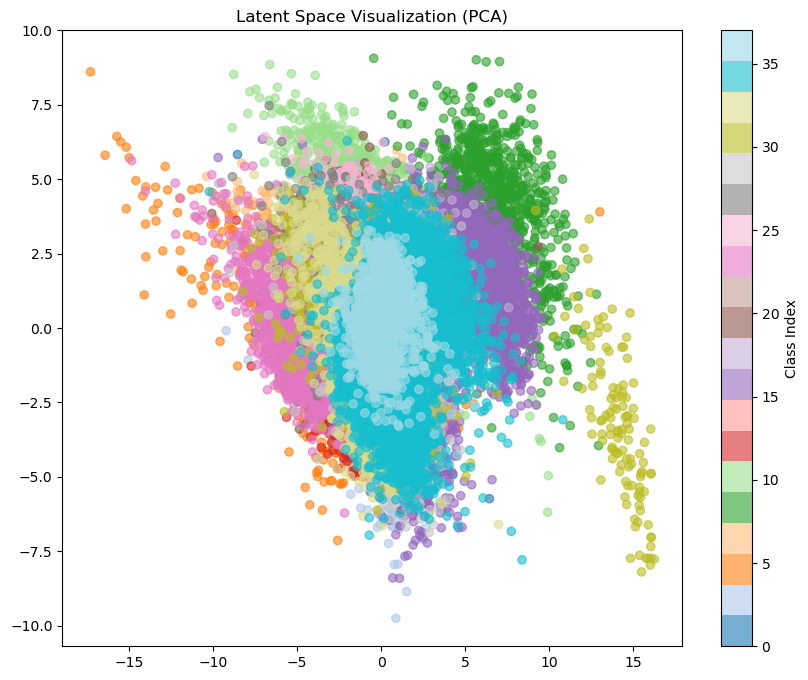

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC        
from sklearn.metrics import accuracy_score   
from sklearn.decomposition import PCA        

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_diseased_latent, y_disease_labels, test_size=0.2, random_state=SEED)
svm = SVC(kernel='rbf', gamma='auto', C=1.0)
svm.fit(X_train_d, y_train_d)
y_pred_d = svm.predict(X_test_d)
acc = accuracy_score(y_test_d, y_pred_d)
print(f"Disease classification accuracy (SVM on latent space): {acc:.4f}")

pca = PCA(n_components=2)
latent_pca = pca.fit_transform(X_latent)
plt.figure(figsize=(10,8))
scatter = plt.scatter(latent_pca[:,0], latent_pca[:,1], c=y_full, cmap='tab20', alpha=0.6)
plt.colorbar(scatter, label='Class Index')
plt.title('Latent Space Visualization (PCA)')
plt.savefig('latent_pca.png')
plt.show()

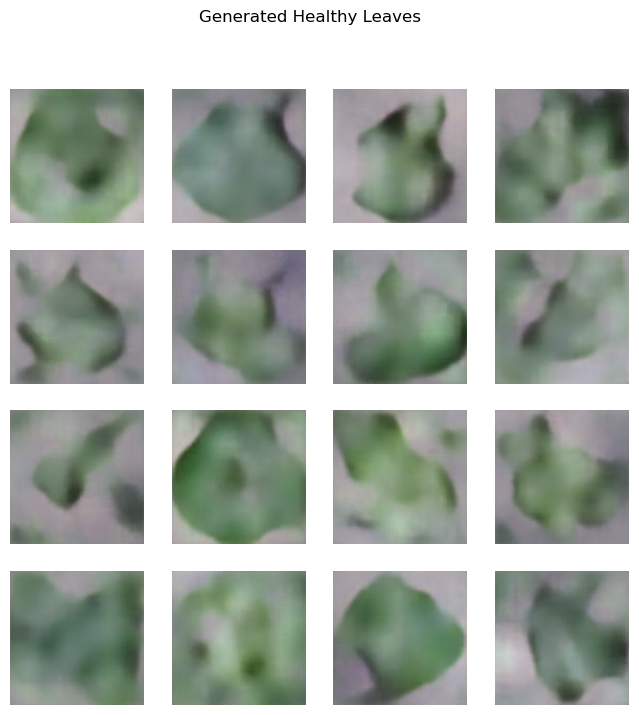

In [9]:
def generate_healthy_leaves(model, num_images=16, latent_dim=128, device=device): 
    model.eval()
    with torch.no_grad():
        z = torch.randn(num_images, latent_dim).to(device)
        gen_images = model.decoder(z).cpu()
        
    fig, axes = plt.subplots(4, 4, figsize=(8,8))
    for i, ax in enumerate(axes.flat):
        img = gen_images[i].permute(1,2,0).numpy()
        ax.imshow(img)
        ax.axis('off')
    plt.suptitle('Generated Healthy Leaves')
    plt.savefig('generated_healthy.png')
    plt.show()

vae = VAE(latent_dim=128)
vae.load_state_dict(torch.load('models/vae_healthy.pth', map_location=device))
vae = vae.to(device) 
generate_healthy_leaves(vae, num_images=16, device=device)

In [10]:
def predict_anomaly(image_tensor, model, threshold, device=device): 
    model.eval()
    with torch.no_grad():
        recon, _, _ = model(image_tensor.unsqueeze(0).to(device))
        error = F.mse_loss(recon, image_tensor.unsqueeze(0).to(device)).item()
    return error > threshold, error

if len(diseased_dataset) > 0:
    diseased_sample = diseased_dataset[0][0]  
    is_diseased, err = predict_anomaly(diseased_sample, vae, threshold, device=device)
    print(f"Sample disease leaf reconstruction error: {err:.6f} > threshold? {is_diseased}")
else:
    print("No diseased instances structural options loaded to complete inference calculation verification.")

Sample disease leaf reconstruction error: 0.005650 > threshold? False
